In [8]:
# Reading Train Data
import pandas as pd
df = pd.read_csv("Dataset/train.csv")
df_test = pd.read_csv("Dataset/test.csv")
df_submission = pd.read_csv("Dataset/sample_submission.csv")

In [9]:
continues=["Age", "Annual Income", "Number of Dependents", "Health Score", "Previous Claims", "Vehicle Age", "Credit Score", "Insurance Duration", "Policy_start_year", "Policy_start_month", "Policy_start_day"]
categories = ["Gender", "Marital Status", "Education Level", "Occupation", "Location", "Policy Type", "Customer Feedback", "Smoking Status", "Exercise Frequency", "Property Type"]

In [10]:
# Checking for missing values
df.isnull().sum()

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [11]:
# Handling Missing Values
for col in df.columns:
    if col == "Policy Start Date" :
        df[col].fillna(method='ffill', inplace=True)
    elif col in categories:
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\nirma\AppData\Local\Temp\ipykernel_19948\2622471259.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\nirma\AppData\Local\Temp\ipykernel_19948\2622471259.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [12]:
# Feature Engineering
df.set_index("id", inplace=True)
df.drop(columns=["Policy Start Date"], inplace=True)
df.drop(columns=["Customer Feedback"], inplace=True)

In [13]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = enc.fit_transform(df[col])

In [14]:
coor_data=df.corr()

<Axes: >

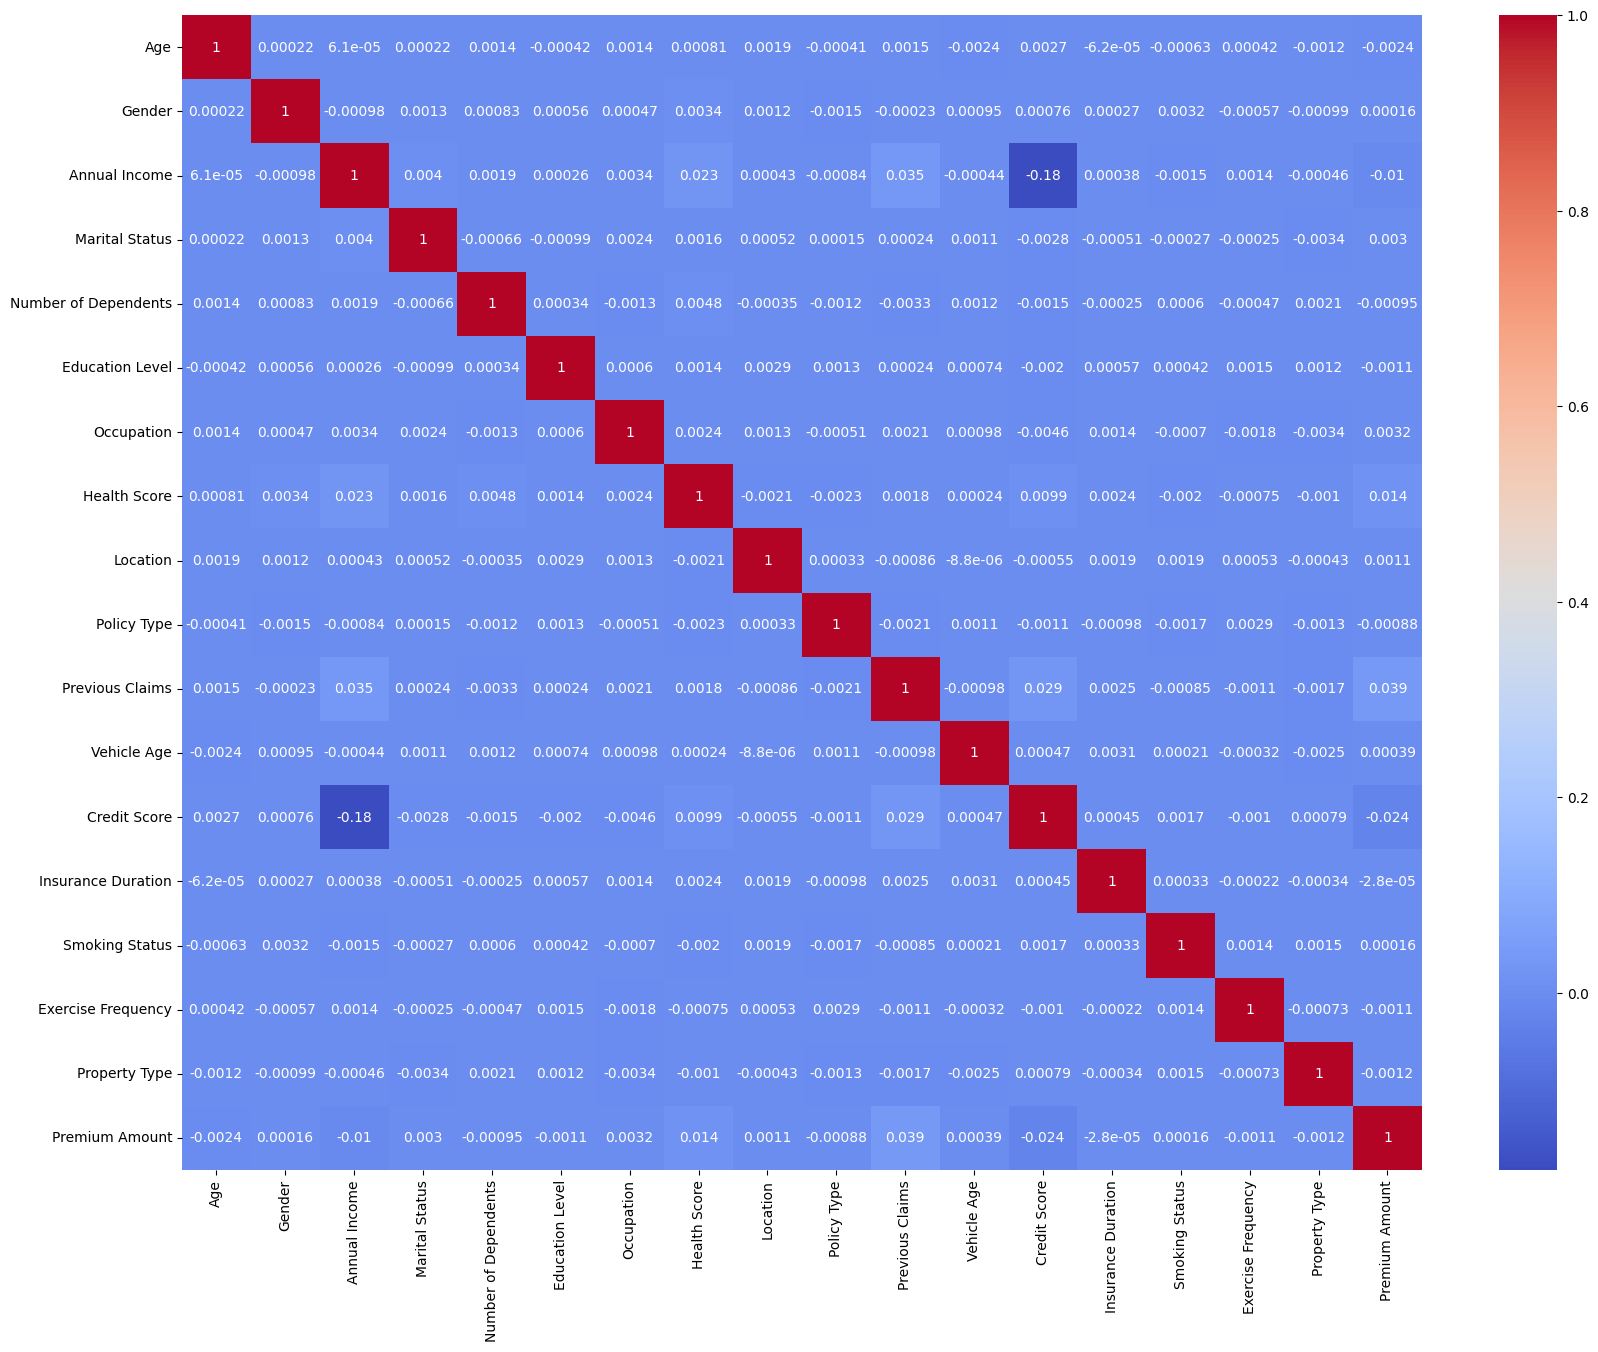

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
import seaborn as sns
sns.heatmap(coor_data, annot=True, cmap="coolwarm")

In [17]:
# Hypothesis Testing
import scipy.stats as stats

#continious vs continious
def two_sample(d1,d2):
    t=0
    f=0
    for i in range(31):
        sample1 = d1.sample(frac=0.03)
        sample2 = d2.sample(frac=0.03)
        t_test,p_value = stats.ttest_ind(sample1,sample2)
        if p_value < 0.05:
            f+=1
        else:
            t+=1
    if t>f:
        return True
    else:
        return False
    
#cat vs cat
def chisquare_test(d1,d2):
    return True if stats.chi2_contingency(pd.crosstab(d1,d2))[1]<0.05 else False

#continious(d1) vs cat(d2)
def annova_test(d1,d2):
    group = df[d2].unique()
    data={}
    for i in group:
        data[i]= df[d1][df[d2]==i]
    fvalue,p_value = stats.f_oneway(*[i for i in data.values()])
    return True if p_value>0.05 else False

In [18]:
# Hypothesis Testing
final = {}
for i in df.columns:
    final[i] = {}
    for j in df.columns:
        if (i in continues) and (j in continues):
            result = two_sample(df[i],df[j])
        elif (i in categories) and (j in categories):
            result = chisquare_test(df[i],df[j])
        elif (i in continues) and (j in categories):
            result = annova_test(i,j)
        elif (i in categories) and (j in continues):
            result = annova_test(j,i)
        if result:
            final[i][j] = 1
        else:
            final[i][j] = 0

<Axes: >

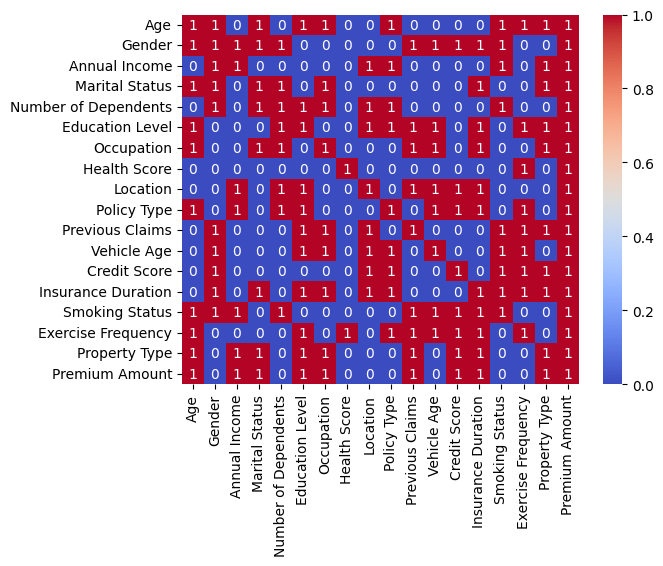

In [19]:
final = pd.DataFrame(final)
sns.heatmap(final, annot=True, cmap="coolwarm")

In [ ]:
# identify skew df["col"].skew() -> flow in x axis
# case1 - output between -0.5 to 0.5 - less skewness , no transformation is required
# case 2 - output in between -1 to -0.5 or 0.5 to 1 - mild skew , transformation is can be considered
# case 3 - output in  <-1 or 1 < - strong skew , transformation is required

# identify skew df["col"].kurtosis() -> flow in y axis
# case1 - output between -3 to 3 - less kurtosis , no transformation is required
# case 2 - output in between -6 to -3 or 3 to 6 - mild kurtosis , transformation is can be considered
# case 3 - output in  <-6 or 6 < - strong kurtosis , transformation is required

In [20]:
for i in df.columns:
    if i in continues:
        print(i,df[i].skew(),df[i].kurtosis())

Age -0.012124039077023415 -1.1663719030495083
Annual Income 1.522953747839693 2.0168911971726335
Number of Dependents -0.011889218273089 -1.1359675994503078
Health Score 0.30730212749903657 -0.6348953667048636
Previous Claims 1.087648956085992 2.373031899167666
Vehicle Age -0.02041004734788034 -1.2064388219983704
Credit Score -0.1257859072474886 -0.8414241913235951
Insurance Duration -0.008793288411603855 -1.2372502481407737


In [23]:
Boxcox = [-2, -1, -0.5, 0, 0.5, 1, 2 ]
for i in Boxcox:
    df["Annual Income New"]=stats.boxcox(df["Annual Income"], lmbda=i)
    df["Previous Claims New"]=stats.boxcox(df["Previous Claims"], lmbda=i)
    print(i,"Annual Income New",df["Annual Income New"].skew(),df["Annual Income New"].kurtosis())
    print(i,"Previous Claims New",df["Previous Claims New"].skew(),df["Previous Claims New"].kurtosis())

-2 Annual Income New -663.4684192199719 546617.5877385559


d:\Learn\Guvi\DS\project\Premium Calculation_ML\env\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
d:\Learn\Guvi\DS\project\Premium Calculation_ML\env\Lib\site-packages\pandas\core\nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


-2 Previous Claims New nan nan
-1 Annual Income New -113.46016401900052 30085.74576986087
-1 Previous Claims New nan nan
-0.5 Annual Income New -9.854893493462159 202.19241183064707
-0.5 Previous Claims New nan nan
0 Annual Income New -1.0495548514957986 1.4553794608085266
0 Previous Claims New nan nan
0.5 Annual Income New 0.4971849183192839 -0.2584736227749973
0.5 Previous Claims New -0.49934643495159164 -0.6633657132108794
1 Annual Income New 1.522953747839693 2.0168911971726335
1 Previous Claims New 1.0876489560859919 2.3730318991676635
2 Annual Income New 2.934788318084589 8.944968446700184
2 Previous Claims New 4.303213810996943 31.247498188370013


In [24]:
df["Annual Income"]=stats.boxcox(df["Annual Income"], lmbda=0.5)
df["Previous Claims"]=stats.boxcox(df["Previous Claims"], lmbda=0.5)
df.drop(columns=["Annual Income New","Previous Claims New"], inplace=True)